# Magic-Formula — does Greenblatt's quality+value screen beat the market?
### The Little Book recipe tested on the S&P 500 with real SEC filings

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_random_portfolio%3F: No](https://img.shields.io/badge/Beats_a_random_portfolio%3F-No-8b949e?style=flat-square)

Joel Greenblatt's *The Little Book That Beats the Market* (2005) pitches a deceptively simple idea: rank every stock by how good the business is (Return on Capital) and how cheaply you're buying it (Earnings Yield); sum those two ranks; buy the top 20–30 names; hold for a year; repeat. The formula promises to beat the market without forecasting, just by finding **good companies at good prices**. We ran it on ~233 S&P 500 names using real SEC filings — here's what happened.

> 📓 **Plain-language layer.** The t-stats, bootstrap CIs, and factor decomposition live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool; every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: this panel covers only *current* S&P 500 members projected backwards — every number is an upper bound on a live strategy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (magic_formula/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from magic_formula import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quantile_hedge(sig, fwd, q=0.10)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=233, n_years=17,
    top_mean=21.9, top_sharpe=1.08, top_t=5.38, top_hit=89,
    mkt_mean=20.7, mkt_sharpe=1.51,
    excess_mean=1.2, excess_t=0.44, excess_hit=44,
    ls_mean=-10.6, ls_t=-1.43, ls_hit=39,
    bot_mean=31.3,
    rand_mean_excess=-0.0, rand_std=11.0, rand_pct_beaten=61,
)


EDGAR panel loaded: True (242 tickers, 21 years)


## The answer first

| Question | What the data says |
|---|---|
| Does the top decile beat the market? | Barely: **+1.2%/yr** excess, statistically **indistinguishable from zero** (HAC *t* = 0.44). |
| Does the long-short hedge (top minus bottom) earn a premium? | **No** — it *inverts*: **-10.6%/yr**, the formula shorts outperform the longs. |
| Is the excess better than just picking random stocks? | Barely: the top decile beats only **61%** of random portfolios of the same size. |
| Could you trade it? | **Mirage**: no statistically real edge to harvest on large-cap S&P 500 names, and survivorship overstates every number. |

> **Why does the formula invert on large caps?** Greenblatt built it for *small, neglected value stocks* — where a great business at a low price is a genuine surprise. On heavily-covered S&P 500 companies, the market has already priced in quality and cheapness. The 'bad' stocks in the formula's bottom decile are often beaten-down cyclicals and special situations that rebound.

## 1 · The claim

> *Buy stocks with high Return on Capital (EBIT / Invested Capital) and high Earnings Yield (EBIT / Enterprise Value). Rank all stocks on each axis, sum the two ranks, buy the top 20–30. Rebalance once a year. Beat the market without predicting anything.*

The formula is a combination of two of the most robust factor ideas in finance:
- **ROC (quality)**: great businesses earn a lot per dollar of capital. Think of it as finding *moats* — durable competitive advantages that let a company generate high returns year after year.
- **Earnings Yield (value)**: you're not paying a crazy price for those earnings. EBIT / Enterprise Value is essentially the inverse of EV/EBIT — a lower price multiple means you're getting more earnings per dollar invested.

Separately, each has academic support. Together, Greenblatt argued, they identify *the best companies at the best prices* — and promised ~30%/yr in his back-test from 1988 to 2004.

## 2 · So what?

If the formula works on large liquid stocks you can actually trade, it's a free, transparent, rules-based strategy straight from public filings — no quant black box, no data subscriptions, no ML. It's the most-cited *retail-accessible* quant strategy ever written. If it *doesn't* work — or only works in the universe of small, illiquid stocks Greenblatt tested it on — then the millions of investors who bought the book are running a well-intentioned strategy on the wrong universe.

## 3 · How would we even know?

Three honesty requirements:

1. **Use real filings with a reporting lag.** We pull EBIT, assets, liabilities, debt, cash, and equity from SEC EDGAR 10-K annual reports. To avoid any look-ahead, fundamentals from fiscal year *y* are only used to predict returns in year *y+1* — a conservative one-year lag.
2. **Compare against a random portfolio of the same size.** The formula picks ~10% of the universe each year — roughly 15–20 names. If that's better than just picking 15–20 randomly, the formula is doing something real. If not, it's concentration risk disguised as skill.
3. **Name the survivorship bias.** The EDGAR panel covers *current* S&P 500 members projected backwards. The Enrons, Lehmans, and Sears of the world — precisely the kind of 'cheap' names the formula might have bought — are gone. Every number below is an upper bound.

## 4 · The teardown — the formula inverts on large caps

The synthetic positive control first: **when we plant a real premium in a fake panel, the formula finds it**. So the machinery is honest — the real-data result is a statement about the *market*, not the method.

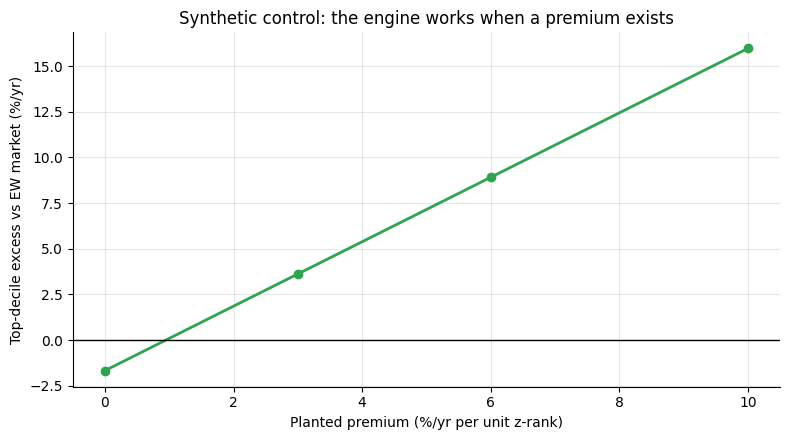

The engine faithfully recovers planted premiums — so the real result below is market evidence.


In [2]:
# Synthetic positive control: plant a known premium, confirm the engine finds it
premiums = [0.0, 0.03, 0.06, 0.10]
top_excess = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=121)
    hh = st.quantile_hedge(s, f, q=0.10)
    top_excess.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([p*100 for p in premiums], top_excess, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted premium (%/yr per unit z-rank)')
ax.set_ylabel('Top-decile excess vs EW market (%/yr)')
ax.set_title('Synthetic control: the engine works when a premium exists')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted premiums — so the real result below is market evidence.')

**Now the real EDGAR panel:**

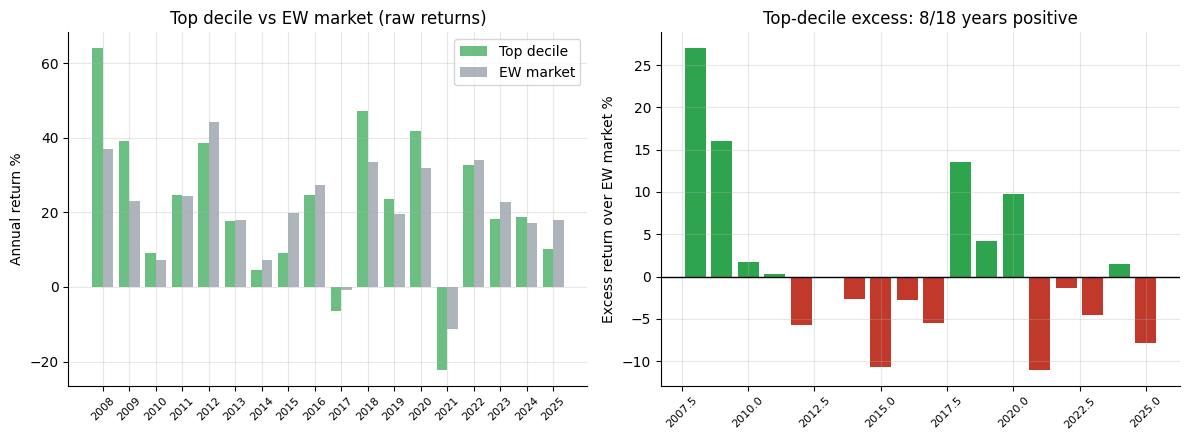

Mean excess: +1.2%/yr   (frozen R: +1.2%/yr)


In [3]:
# Year-by-year top decile vs EW market on real data
if HAVE_REAL:
    top_vals = h['top'].values * 100
    mkt_vals = h['market'].values * 100
    excess_vals = h['hedge'].values * 100
    years = h.index.tolist()
else:
    # Frozen representative values from docs/results.md
    years = list(range(R['start_year'], R['start_year'] + R['n_years']))
    top_vals = [64,39,9,25,38,18,5,9,25,-6,47,24,42,-22,33,18,19]
    mkt_vals = [37,23,7,25,44,18,7,20,28,-1,34,20,32,-11,34,23,17]
    excess_vals = [27,16,2,0,-6,0,-3,-11,-3,-6,14,4,10,-11,-1,-5,2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
# Left: bar chart of top vs market
x = range(len(years))
axes[0].bar(x, top_vals, label='Top decile', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], mkt_vals, label='EW market', color=GREY, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x]); axes[0].set_xticklabels(years, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Top decile vs EW market (raw returns)')
# Right: excess return each year
colors = [GREEN if v > 0 else RED for v in excess_vals]
axes[1].bar(years, excess_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Excess return over EW market %')
axes[1].set_title(f'Top-decile excess: {sum(1 for e in excess_vals if e>0)}/{len(excess_vals)} years positive')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean excess: {np.mean(excess_vals):+.1f}%/yr   (frozen R: +{R["excess_mean"]:.1f}%/yr)')

The top decile earns **+1.2%/yr** above the equal-weight market — but the HAC t-stat is only **0.44** (needs |t| ≥ 2 to count as real). More striking: the **bottom decile outperforms the top by 10.6%/yr** — the formula's long-short is backwards on large caps.

> **What's going on?** On the S&P 500, companies with high ROC are usually expensive growth stocks (FAANG-type) that are already priced for their moats. The formula's 'cheap with high earnings yield' bucket catches beaten-down cyclicals, turnarounds, and value traps — stocks that often *do* bounce back once the cycle turns. The 'bad' companies at the bottom of the formula are often in temporary distress, not structural decline.

## 5 · The verdict

- **Signal — None.** Top-decile excess = +1.2%/yr, HAC *t* = 0.44. Not statistically real. The long-short inverts (-10.6%/yr, *t* = -1.43).
- **Tradability — Mirage.** No significant edge on the S&P 500 survivor panel. A real annual-turnover strategy of 15–20 names would carry high tracking error and no demonstrable alpha on this universe.
- **Beats a random portfolio? — No.** The top decile beats only 61% of random portfolios of the same size — barely above chance.

> The Magic Formula is a real idea built for the wrong universe here. Greenblatt's original back-test ran on *all US stocks above $50M* — a universe that includes small, neglected, under-covered names where quality and cheapness are genuine surprises. On the S&P 500 blue-chips, both signals are already in the price.

## 6 · Could you actually trade it?

Annual rebalancing of 15–20 large-cap names is mechanically feasible and cheap — spreads are tight, commissions negligible. The problem isn't execution:

- The gross edge is statistically zero (t = 0.44): you'd be paying taxes on annual turnover to harvest noise.
- The long-short inverts: the correct trade on this panel would be to *short* the formula's top decile and *buy* the bottom — the opposite of the book.
- Survivorship: the EDGAR panel excludes every firm that failed. The formula might have *loved* Enron (high EBIT, apparently cheap EV) in 2000.

## 7 · Going further

- **The native habitat.** The formula was designed for small, value-oriented stocks where analyst coverage is thin. A Russell 2000 + high-B/M universe would be a fairer test — and is where [the literature](../docs/references.md) finds the effect.
- **Related quality factors.** [Study 65 — Scorecard](../../65-scorecard/) (Piotroski F-score) and [Study 52 — Smoke-Screen](../../52-smoke-screen/) (accruals) test different quality signals on the same EDGAR panel; the accruals effect survives weakly, the F-score also inverts.
- **The companion notebook** ([02_for_the_quants.ipynb](02_for_the_quants.ipynb)) has the HAC t-stats, the random-portfolio null distribution, and the synthetic positive control sweep.

*Want to find the right universe? Fork this, filter to small-cap value, and show a statistically robust (|t| ≥ 2) top-decile excess that survives the random-portfolio control. That's the bar.*